In [54]:
import pandas as pd
import numpy as np

In [55]:
fraud_df = pd.read_csv("../data/raw/fraud_data.csv")
ip_df = pd.read_csv("../data/raw/IpAddress_to_Country.csv")

In [56]:
fraud_df.head()

,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [57]:
ip_df.head()

,lower_bound_ip_address,upper_bound_ip_address,country
0,100000000,149999999,United States
1,150000000,199999999,Canada
2,200000000,249999999,United Kingdom
3,250000000,299999999,Germany
4,300000000,349999999,France


In [58]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src.geolocation import prepare_ip_df_bounds, map_ip_to_country

fraud_df['ip_int'] = fraud_df['ip_address'].astype('int64')

In [59]:
# Ensure IP range boundaries are integers and prepare ip_df
ip_df = prepare_ip_df_bounds(ip_df)

In [60]:
# Map ip integers to countries using the vectorized helper
fraud_df = map_ip_to_country(fraud_df, ip_df, ip_int_col='ip_int', country_col='country')

In [61]:
# Count total transactions per country
transaction_counts = fraud_df['country'].value_counts()
transaction_counts.head(20)

country
Unknown           136570
United Kingdom      1948
Australia           1855
India               1849
Brazil              1808
Canada              1798
United States       1768
Germany             1765
France              1751
Name: count, dtype: int64

In [62]:
# Analyze fraud rate by country
# ------------------------------------------------------------
# 'class' = 1 → fraudulent transaction
# Mean gives fraud rate per country

# Compute fraud rate per country
fraud_rate = fraud_df.groupby('country')['class'].mean().sort_values(ascending=False)
fraud_rate.head(10)

country
United Kingdom    0.115503
Canada            0.104561
United States     0.094457
Unknown           0.094047
France            0.091947
Brazil            0.086836
India             0.081666
Germany           0.074221
Australia         0.068464
Name: class, dtype: float64

In [63]:
# Merge counts and fraud rate into a single DataFrame
country_summary = pd.DataFrame({
    'transactions': transaction_counts,
    'fraud_rate': fraud_rate
}).sort_values(by='fraud_rate', ascending=False)

country_summary.head(20)

,transactions,fraud_rate
country,,
United Kingdom,1948,0.115503
Canada,1798,0.104561
United States,1768,0.094457
Unknown,136570,0.094047
France,1751,0.091947
Brazil,1808,0.086836
India,1849,0.081666
Germany,1765,0.074221
Australia,1855,0.068464


/tmp/ipykernel_6974/2616115822.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)
/tmp/ipykernel_6974/2616115822.py:14: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)


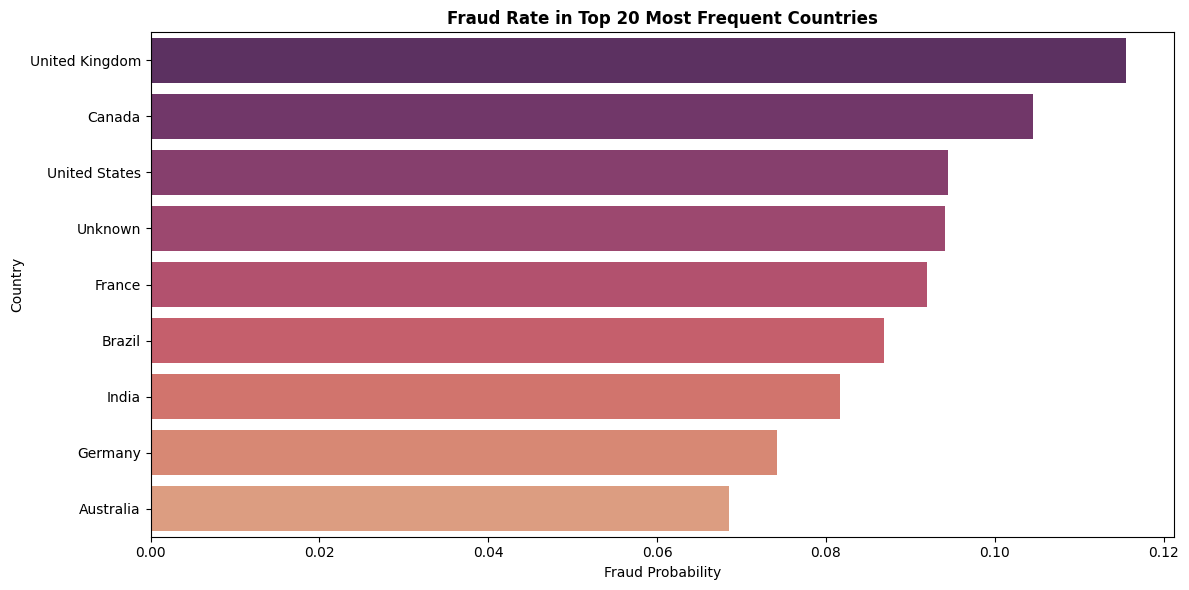

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot fraud rate for the top 20 most frequent countries
top_countries = fraud_df['country'].value_counts().head(20).index
country_fraud = (
    fraud_df[fraud_df['country'].isin(top_countries)]
    .groupby('country')['class'].mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(12, 6))
sns.barplot(x='class', y='country', data=country_fraud, palette="flare_r", errwidth=0)
plt.title('Fraud Rate in Top 20 Most Frequent Countries', fontweight="bold")
plt.xlabel('Fraud Probability')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../notebooks/ecommerce_country_fraud.png', dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_6974/2726274320.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
/tmp/ipykernel_6974/2726274320.py:18: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
/tmp/ipykernel_6974/2726274320.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['No', 'Yes'])


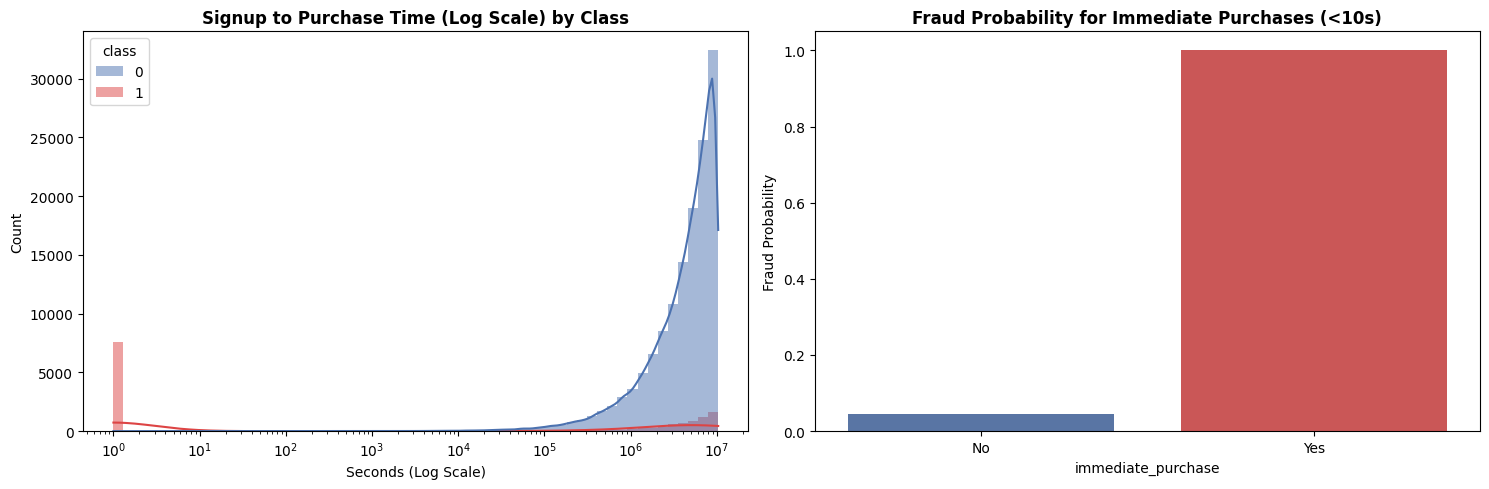

Immediate purchase counts: 7,600 transactions


In [65]:
# Ensure datetime columns exist before computing velocity
fraud_df['signup_time'] = pd.to_datetime(fraud_df['signup_time'])
fraud_df['purchase_time'] = pd.to_datetime(fraud_df['purchase_time'])

# Calculate signup-to-purchase time (transaction velocity in seconds)
fraud_df['signup_to_purchase_time'] = (fraud_df['purchase_time'] - fraud_df['signup_time']).dt.total_seconds()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Log-scaled velocity distribution
sns.histplot(fraud_df, x='signup_to_purchase_time', hue='class', bins=60, kde=True,
             common_norm=False, log_scale=True, palette=["#4C72B0", "#DD4444"], ax=axes[0], edgecolor="none")
axes[0].set_title('Signup to Purchase Time (Log Scale) by Class', fontweight="bold")
axes[0].set_xlabel('Seconds (Log Scale)')

# Immediate purchase flag (under 10 seconds between signup & purchase)
fraud_df['immediate_purchase'] = (fraud_df['signup_to_purchase_time'] < 10).astype(int)
sns.barplot(x='immediate_purchase', y='class', data=fraud_df, ax=axes[1], palette=["#4C72B0", "#DD4444"], errwidth=0)
axes[1].set_title('Fraud Probability for Immediate Purchases (<10s)', fontweight="bold")
axes[1].set_xticklabels(['No', 'Yes'])
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()

print(f"Immediate purchase counts: {fraud_df['immediate_purchase'].sum():,} transactions")

/tmp/ipykernel_6974/387766603.py:11: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='device_sharing_count', y='class', data=fraud_df, ax=axes[0], color="#DD4444", errwidth=0)
/tmp/ipykernel_6974/387766603.py:17: FutureWarning: 

The `errwidth` parameter is deprecated. And will be removed in v0.15.0. Pass `err_kws={'linewidth': 0}` instead.

  sns.barplot(x='ip_sharing_count', y='class', data=fraud_df, ax=axes[1], color="#DD4444", errwidth=0)


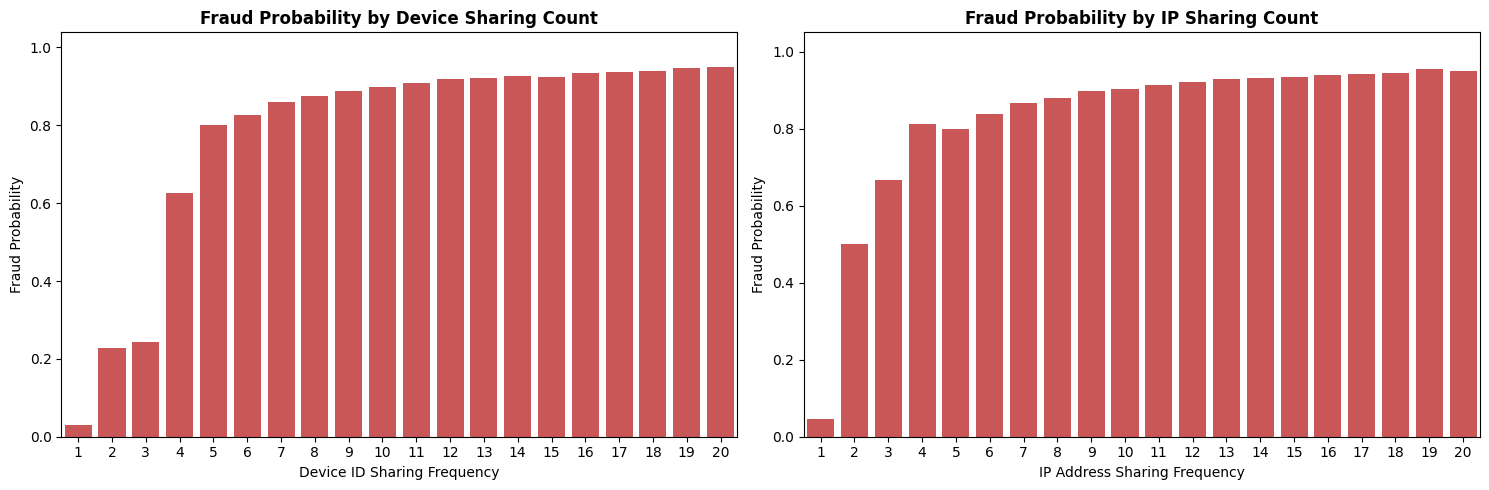

In [66]:
# Calculate sharing frequencies for device_id and ip_address
device_counts = fraud_df['device_id'].value_counts()
ip_counts = fraud_df['ip_address'].value_counts()

fraud_df['device_sharing_count'] = fraud_df['device_id'].map(device_counts)
fraud_df['ip_sharing_count'] = fraud_df['ip_address'].map(ip_counts)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Device sharing count vs Class
sns.barplot(x='device_sharing_count', y='class', data=fraud_df, ax=axes[0], color="#DD4444", errwidth=0)
axes[0].set_title('Fraud Probability by Device Sharing Count', fontweight="bold")
axes[0].set_xlabel('Device ID Sharing Frequency')
axes[0].set_ylabel('Fraud Probability')

# IP sharing count vs Class
sns.barplot(x='ip_sharing_count', y='class', data=fraud_df, ax=axes[1], color="#DD4444", errwidth=0)
axes[1].set_title('Fraud Probability by IP Sharing Count', fontweight="bold")
axes[1].set_xlabel('IP Address Sharing Frequency')
axes[1].set_ylabel('Fraud Probability')

plt.tight_layout()
plt.show()